In [1]:
# HealthGuard AI - Diabetes EDA
# Author: HealthGuard AI Team
# Date: 2026
# Purpose: Exploratory Data Analysis of Diabetes Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

print("=" * 50)
print("   HealthGuard AI - Diabetes EDA")
print("=" * 50)
print("Libraries Loaded Successfully!")

   HealthGuard AI - Diabetes EDA
Libraries Loaded Successfully!


In [2]:
# Load Diabetes Dataset
# Source: UCI Machine Learning Repository / Kaggle
# Records: 768 patients, 9 columns

df = pd.read_csv("E:/HealthGuard_AI/data/raw/diabetes.csv")

print("Dataset Loaded Successfully!")
print("=" * 50)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("=" * 50)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Dataset Loaded Successfully!
Total Rows: 768
Total Columns: 9

Column Names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 Rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Basic Dataset Information
# Check data types and memory usage

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# Basic Statistical Analysis
# Check mean, median, min, max of each column

print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
df.describe().round(2)

BASIC STATISTICS


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [5]:
# Check Missing Values
# Note: 0 values in medical data = missing values

print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)

# Check NaN values
print("NaN Values:")
print(df.isnull().sum())

# Check Zero values in medical columns
print("\nZero Values (Actually Missing):")
zero_cols = ['Glucose', 'BloodPressure', 
             'SkinThickness', 'Insulin', 'BMI']

for col in zero_cols:
    zeros = (df[col] == 0).sum()
    percentage = (zeros / len(df)) * 100
    print(f"{col}: {zeros} zeros ({percentage:.1f}%)")

MISSING VALUES CHECK
NaN Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero Values (Actually Missing):
Glucose: 5 zeros (0.7%)
BloodPressure: 35 zeros (4.6%)
SkinThickness: 227 zeros (29.6%)
Insulin: 374 zeros (48.7%)
BMI: 11 zeros (1.4%)


In [6]:
# Check Duplicate Rows
# Duplicates can affect model accuracy

print("=" * 50)
print("DUPLICATE CHECK")
print("=" * 50)

duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates Removed!")
    print(f"New Shape: {df.shape}")
else:
    print("No Duplicates Found! Dataset is Clean.")

DUPLICATE CHECK
Total Duplicate Rows: 0
No Duplicates Found! Dataset is Clean.


TARGET DISTRIBUTION
Diabetes Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

No Diabetes (0): 500 patients
Diabetes (1): 268 patients

No Diabetes: 65.1%
Diabetes: 34.9%


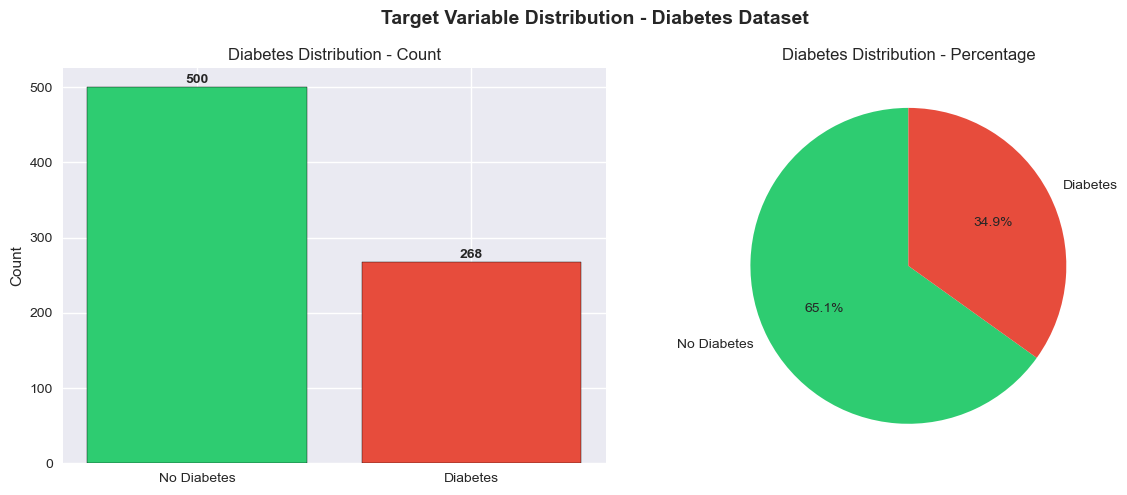

In [7]:
# Target Variable Distribution
# Check how many patients have diabetes vs no diabetes

print("=" * 50)
print("TARGET DISTRIBUTION")
print("=" * 50)

print("Diabetes Distribution:")
print(df['Outcome'].value_counts())
print(f"\nNo Diabetes (0): {(df['Outcome']==0).sum()} patients")
print(f"Diabetes (1): {(df['Outcome']==1).sum()} patients")

percentage = df['Outcome'].value_counts(normalize=True) * 100
print(f"\nNo Diabetes: {percentage[0]:.1f}%")
print(f"Diabetes: {percentage[1]:.1f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count Plot
axes[0].bar(['No Diabetes', 'Diabetes'],
            df['Outcome'].value_counts(),
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black')
axes[0].set_title('Diabetes Distribution - Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['Outcome'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie(df['Outcome'].value_counts(),
            labels=['No Diabetes', 'Diabetes'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Diabetes Distribution - Percentage')

plt.suptitle('Target Variable Distribution - Diabetes Dataset',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

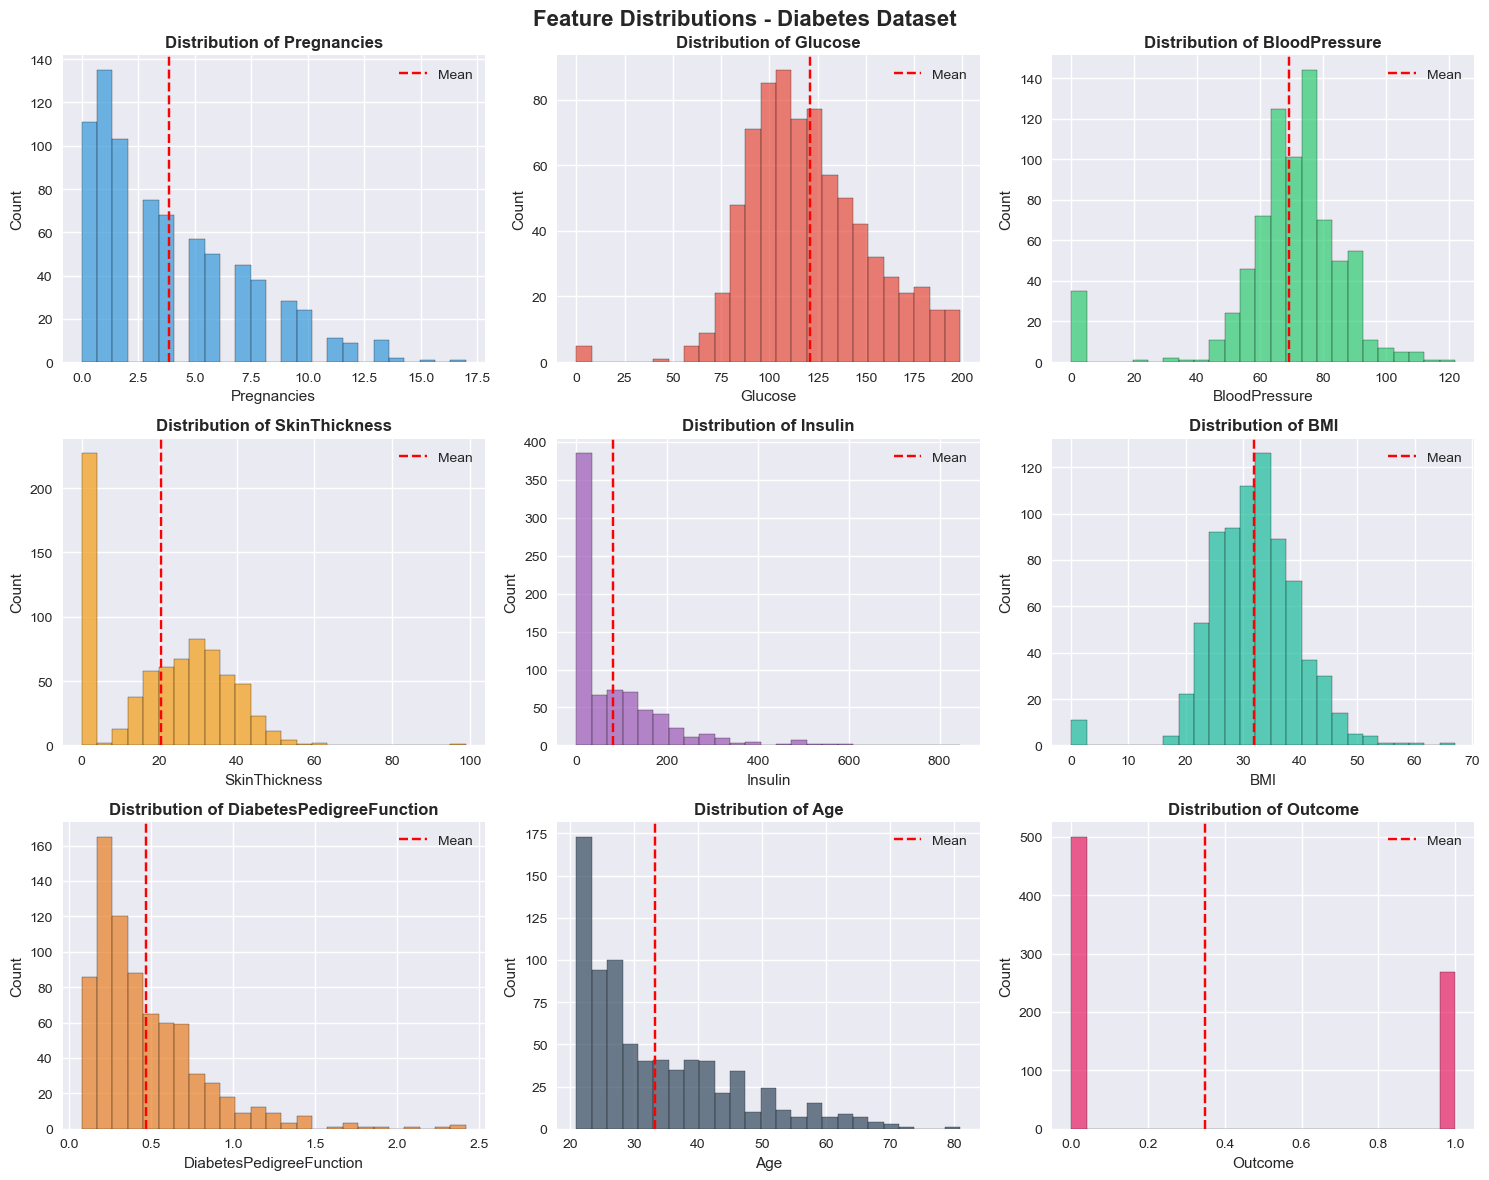

Distribution Analysis Complete!


In [8]:
# Feature Distributions
# Check how each feature is spread across patients

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

columns = df.columns.tolist()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22', '#34495e', '#e91e63']

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=25,
                 color=colors[i],
                 edgecolor='black',
                 alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].mean(), color='red',
                    linestyle='--', label='Mean')
    axes[i].legend()

plt.suptitle('Feature Distributions - Diabetes Dataset',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Distribution Analysis Complete!")

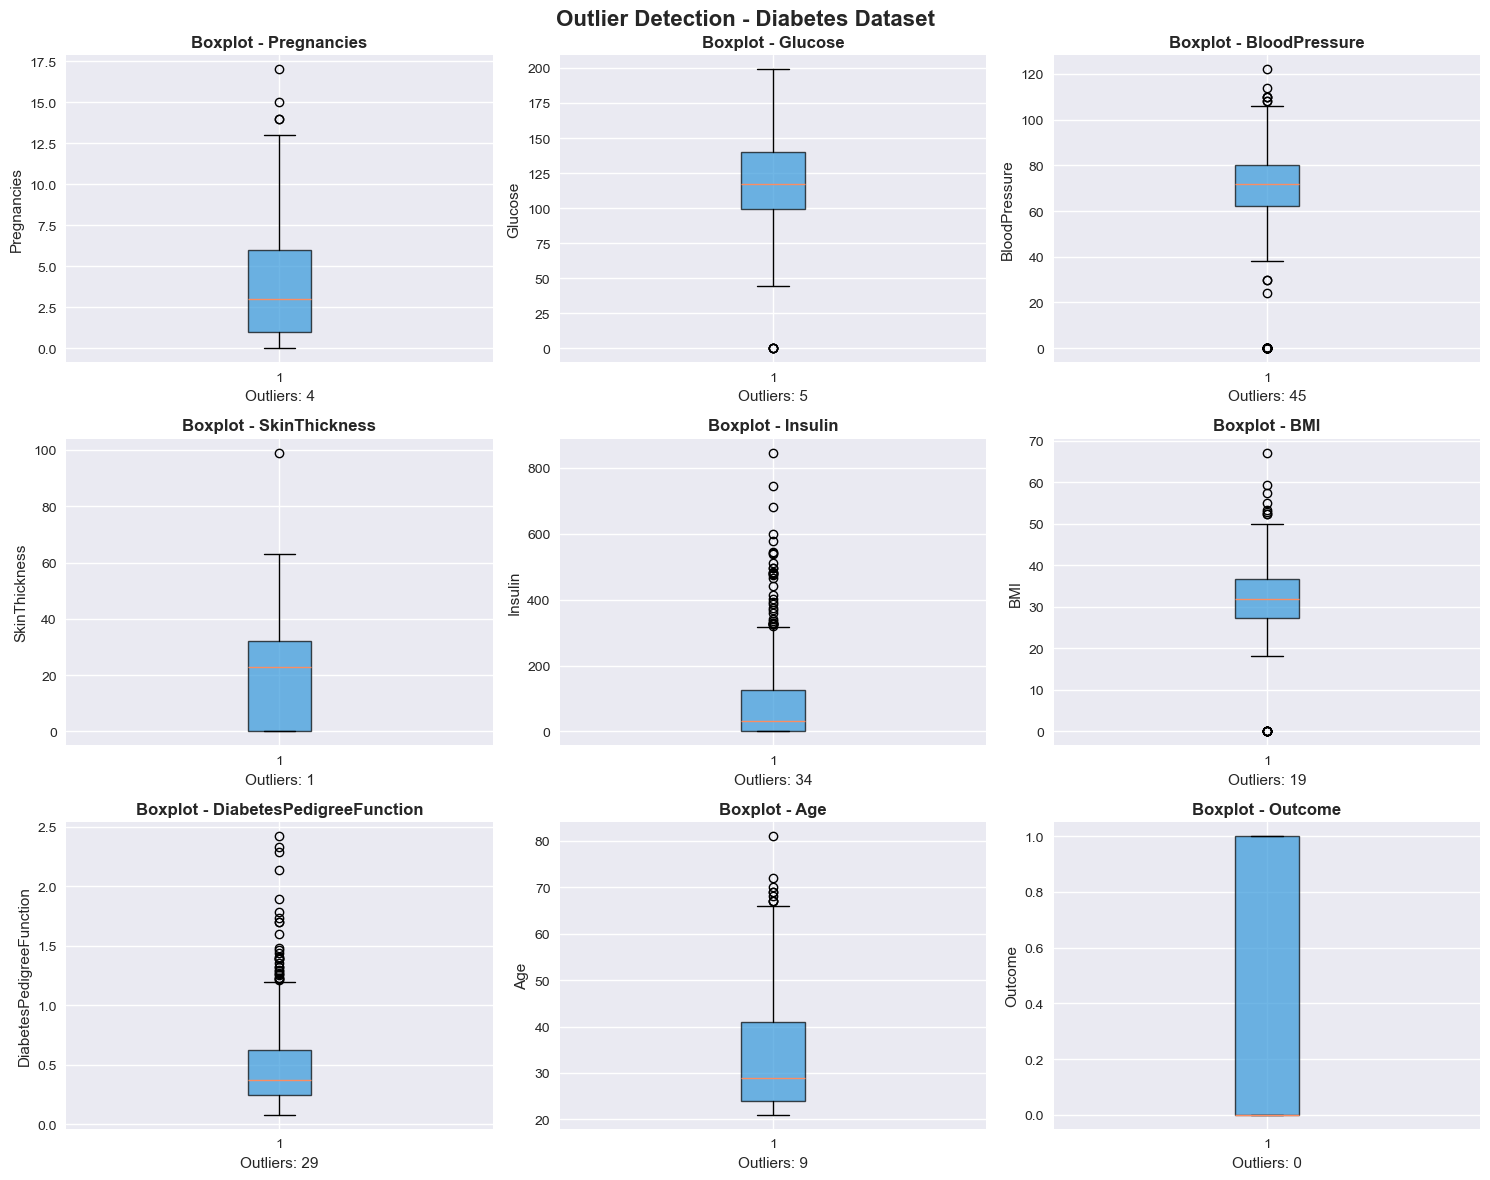

Outlier Detection Complete!


In [9]:
# Outlier Detection Using Boxplots
# Outliers = Extreme values that can affect model

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

columns = df.columns.tolist()

for i, col in enumerate(columns):
    bp = axes[i].boxplot(df[col].dropna(),
                         patch_artist=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(f'Boxplot - {col}', fontweight='bold')
    axes[i].set_ylabel(col)

    # Count outliers
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) |
                (df[col] > (Q3 + 1.5 * IQR))).sum()
    axes[i].set_xlabel(f'Outliers: {outliers}')

plt.suptitle('Outlier Detection - Diabetes Dataset',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Outlier Detection Complete!")

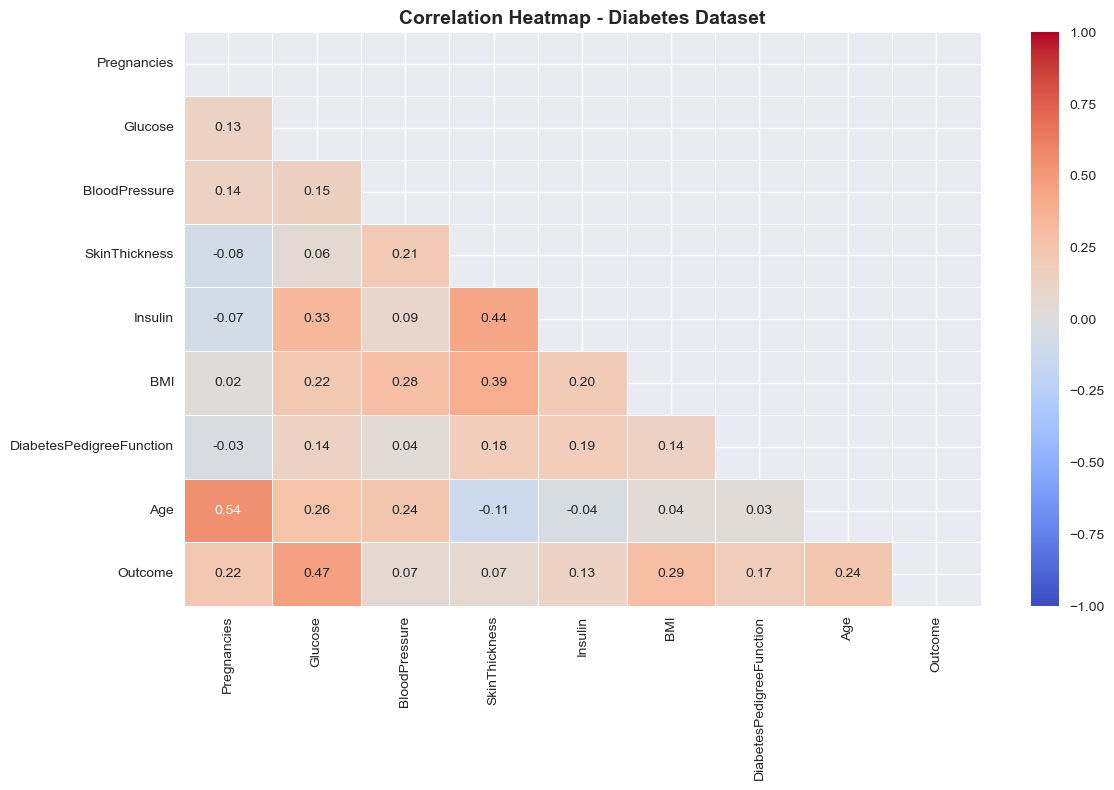

Top Correlations with Diabetes (Outcome):
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [10]:
# Correlation Heatmap
# Shows relationship between all features
# Higher value = Stronger relationship

plt.figure(figsize=(12, 8))
correlation = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            mask=mask,
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap - Diabetes Dataset',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top Correlations with Diabetes (Outcome):")
print(correlation['Outcome'].sort_values(ascending=False))

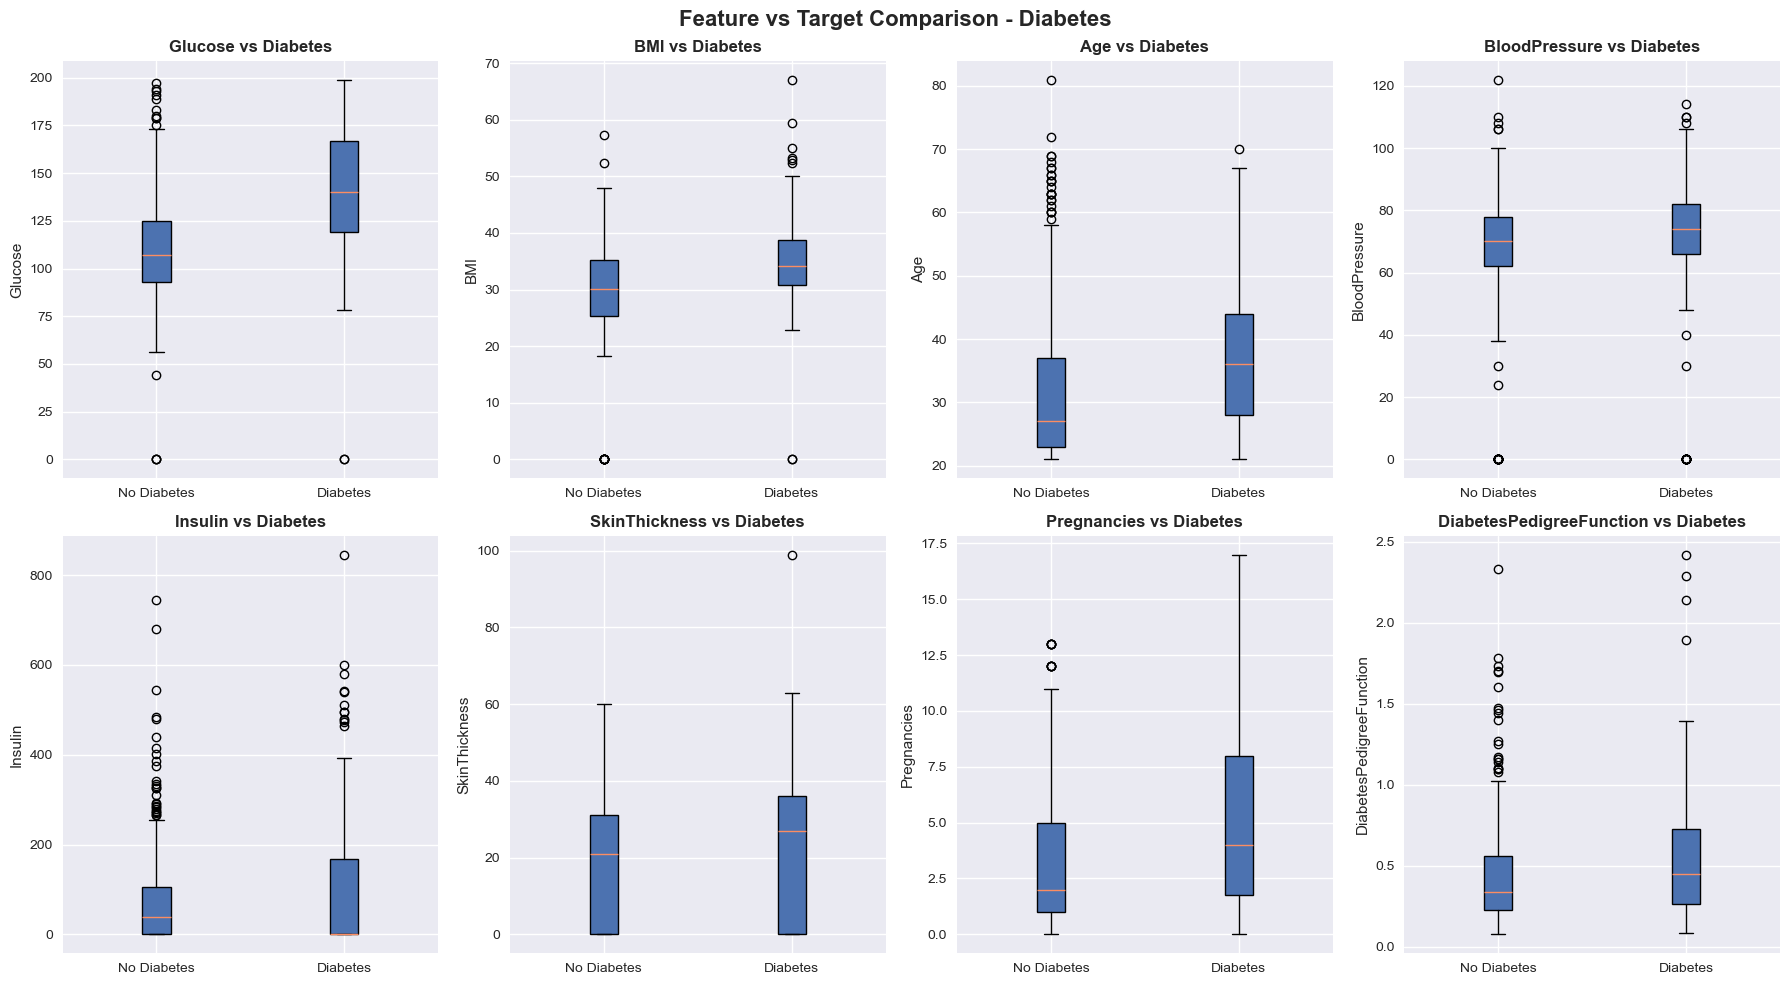

Feature vs Target Analysis Complete!


In [14]:
# Feature vs Target Analysis
# Compare each feature between diabetic and non-diabetic patients

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

features = ['Glucose', 'BMI', 'Age', 'BloodPressure',
            'Insulin', 'SkinThickness', 'Pregnancies',
            'DiabetesPedigreeFunction']

for i, feature in enumerate(features):
    axes[i].boxplot(
        [df[df['Outcome']==0][feature].dropna(),
         df[df['Outcome']==1][feature].dropna()],
        tick_labels=['No Diabetes', 'Diabetes'],
        patch_artist=True
    )
    axes[i].set_title(f'{feature} vs Diabetes',
                      fontweight='bold')
    axes[i].set_ylabel(feature)

plt.suptitle('Feature vs Target Comparison - Diabetes',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Feature vs Target Analysis Complete!")

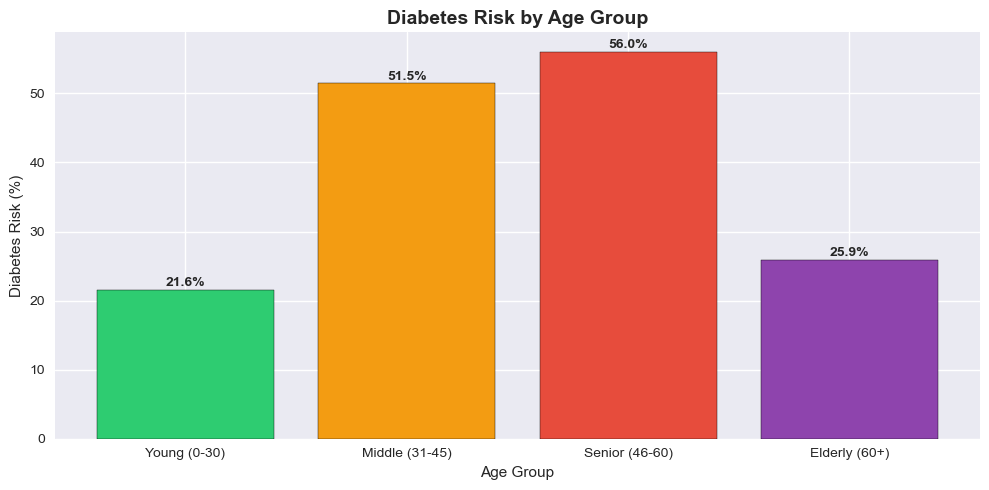

Age Group Analysis Complete!


In [12]:
# Age Group Analysis
# Which age group has more diabetes?

df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 30, 45, 60, 100],
                          labels=['Young (0-30)',
                                  'Middle (31-45)',
                                  'Senior (46-60)',
                                  'Elderly (60+)'])

age_diabetes = df.groupby('Age_Group', observed=True)['Outcome'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(age_diabetes.index,
               age_diabetes.values,
               color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
               edgecolor='black')

for bar, val in zip(bars, age_diabetes.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')

plt.title('Diabetes Risk by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Diabetes Risk (%)')
plt.tight_layout()
plt.show()

# Remove Age_Group column
df = df.drop('Age_Group', axis=1)

print("Age Group Analysis Complete!")

In [13]:
# EDA Summary Report
# Key findings from analysis

print("=" * 60)
print("   DIABETES EDA - SUMMARY REPORT")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Patients: {len(df)}")
print(f"Diabetic Patients: {(df['Outcome']==1).sum()}")
print(f"Non-Diabetic Patients: {(df['Outcome']==0).sum()}")

print("\nKEY FINDINGS:")
print("-" * 40)
print("1. Dataset is imbalanced (65% No, 35% Yes)")
print("2. Glucose is strongest predictor (0.49 correlation)")
print("3. BMI has 0.29 correlation with diabetes")
print("4. Age has 0.24 correlation with diabetes")
print("5. Insulin has most missing values (48.7%)")
print("6. Elderly age group has highest diabetes risk")

print("\nNEXT STEPS:")
print("-" * 40)
print("1. Data Cleaning")
print("2. Feature Engineering")
print("3. Handle Imbalanced Data (SMOTE)")
print("4. Model Training")

print("\nEDA Complete! Ready for Data Cleaning!")
print("=" * 60)

   DIABETES EDA - SUMMARY REPORT

Dataset Shape: (768, 9)
Total Patients: 768
Diabetic Patients: 268
Non-Diabetic Patients: 500

KEY FINDINGS:
----------------------------------------
1. Dataset is imbalanced (65% No, 35% Yes)
2. Glucose is strongest predictor (0.49 correlation)
3. BMI has 0.29 correlation with diabetes
4. Age has 0.24 correlation with diabetes
5. Insulin has most missing values (48.7%)
6. Elderly age group has highest diabetes risk

NEXT STEPS:
----------------------------------------
1. Data Cleaning
2. Feature Engineering
3. Handle Imbalanced Data (SMOTE)
4. Model Training

EDA Complete! Ready for Data Cleaning!
